In [1]:
# Stuff
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline # Interpolation piecewise by SciPy

In [2]:
def newton(f, fprime, x0, atol = 1e-10, rtol = 1e-10, N = 50): # Custom newton root finding (not fully safe)
    
    x = x0
    fx = f(x)

    for _ in range(N):
        
        fpx = fprime(x)
        if np.abs(fpx) < 1e-14:
            return x

        x_new = x - fx / fpx
        err_x = np.abs(x_new - x)

        x, fx = x_new, f(x_new)

        if err_x < (atol + rtol * np.abs(x)):
            return x

    return x

In [3]:
def step(g, gprime, tn, yn, h): # Single Crank–Nicolson step

    f = lambda yn1: yn1 - yn - h / 2.0 * (g(tn + h, yn1) + g(tn, yn))
    fprime = lambda yn1: 1.0 - h / 2.0 * gprime(tn + h, yn1)

    yn1 = newton(f, fprime, yn) # Using custom Newton

    return yn1

In [4]:
# Adaptive CN via Richardson estimation of error
def CN_adaptive(g, gprime, t0, y0, h0, t_end, atol = 1e-05, rtol = 1e-05, min_factor_step = 0.05, max_factor_step = 3.0, safety = 0.9):
    
    # Initial setup
    t, y, h = t0, y0, h0
    ts, ys, errs = [t], [y], [0.0]

    while t < t_end:
        
        h = min(h, t_end - t) # Don't skip the end

        # Two approximations of y(t + h)
        Y1 = step(g, gprime, t, y, h)

        m  = step(g, gprime, t, y, h / 2.0)
        Y2 = step(g, gprime, t + h / 2.0, m, h / 2.0)

        err = 8.0 / 7.0 * (Y2 - Y1) # SIGNED LOCAL error of the full step Y1
        tol = atol + rtol * abs(Y1) # Threshold value
        
        r = abs(err) / tol
        if r < 1.0: # Accept
            
            # Update y, t and lists
            y = Y1
            t += h
            
            ts.append(t)
            ys.append(y)
            errs.append(err)

        # New step h
        factor_h = safety / np.cbrt(r) if (r > 1e-14) else min_factor_step # Compute new factor
        factor_h = max(min_factor_step, min(factor_h, max_factor_step)) # Clip it

        h *= factor_h # Update

    ts, ys, errs = np.array(ts), np.array(ys), np.array(errs) # Array-ing
    errs = np.abs(np.cumsum(errs)) # np.cumsum() to estimate GLOBAL absolute errors

    return ts, ys, errs # Returns t, solution and estimated GLOBAL absolute errors

Let's test:

$$
    y'(t) = \cos(y(t)) ^ 2 \quad y(0) = 0
$$

Solution: $y(t) = \arctan(t)$

In [5]:
def g(t, y): return np.cos(y) ** 2 # rhs of ODE
def gprime(t, y): return - np.sin(2.0 * y) # Partial derivative with respect to y
def sol_exact(t): return np.arctan(t) # Exact solution

# Setup
t0, T = 0.0, 10.0
y0 = 0.0
h0 = 0.1 # Inital step

In [6]:
t, y, err = CN_adaptive( # Solution and estimated absolute errors
    g = g,
    gprime = gprime,
    t0 = t0,
    y0 = y0,
    h0 = h0,
    t_end = T
    )

t, y, err

(array([ 0.        ,  0.03864339,  0.07625932,  0.11456303,  0.15378595,
         0.19419895,  0.23613078,  0.27999811,  0.32635613,  0.37599161,
         0.4301158 ,  0.4908384 ,  0.56270953,  0.66202584,  0.74468739,
         0.82919738,  0.90563264,  0.97895518,  1.05138929,  1.124034  ,
         1.1975891 ,  1.27257433,  1.34941661,  1.42849274,  1.51015328,
         1.59473729,  1.68258239,  1.77403205,  1.86944144,  1.96918238,
         2.07364784,  2.18325623,  2.2984557 ,  2.41972859,  2.5475961 ,
         2.68262337,  2.82542497,  2.97667102,  3.13709396,  3.3074961 ,
         3.48875815,  3.6818488 ,  3.88783565,  4.10789749,  4.34333842,
         4.59560387,  4.86629905,  5.15721004,  5.47032813,  5.80787787,
         6.17234954,  6.56653684,  6.99358074,  7.45702059,  7.96085401,
         8.50960709,  9.10841713,  9.76313029, 10.        ]),
 array([0.        , 0.0386146 , 0.0760938 , 0.11403884, 0.15255493,
        0.19176728, 0.23183072, 0.27294631, 0.31538977, 0.35956469,

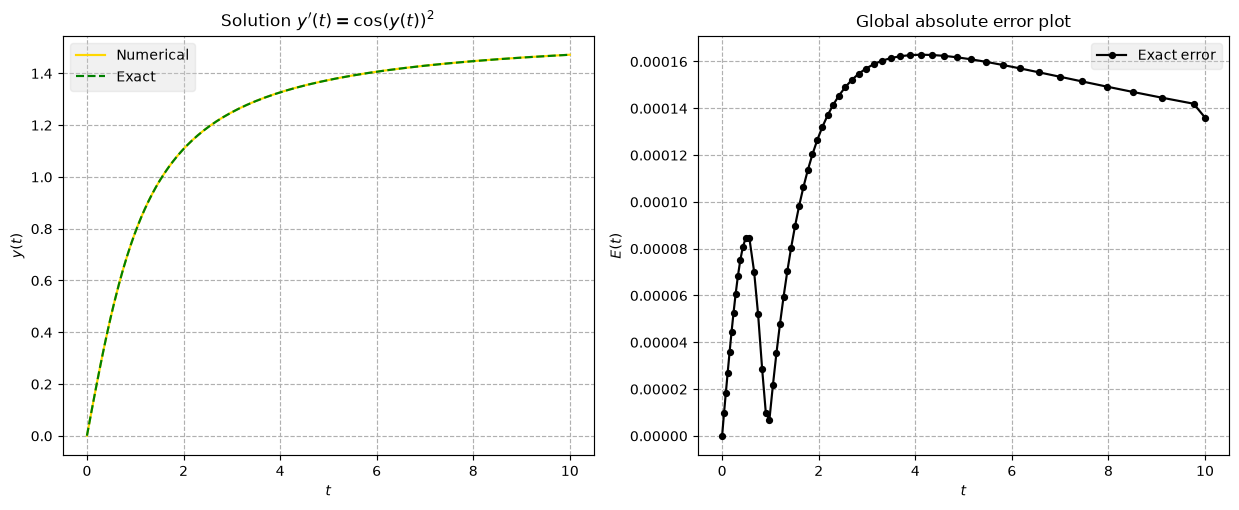

In [7]:
# Plotting
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

exact_sol = sol_exact(t) # Exact solution
exact_err = np.abs(exact_sol - y) # Exact error

# Solution
ax1.set_title(r"Solution $y'(t) = \cos(y(t))^{2}$")
ax1.plot(t, y, color = 'gold', label = 'Numerical')
ax1.plot(t, exact_sol, linestyle = 'dashed', color = 'green', label = 'Exact')
ax1.set_xlabel(r'$t$')
ax1.set_ylabel(r'$y(t)$')
ax1.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax1.grid(linestyle = 'dashed')

# Error
ax2.set_title('Global absolute error plot')
ax2.plot(t, exact_err, linestyle = 'solid', marker = 'o', markersize = 4, color = 'black', label = 'Exact error')
ax2.set_xlabel(r'$t$')
ax2.set_ylabel(r'$E(t)$')
ax2.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax2.grid(linestyle = 'dashed')

plt.tight_layout()
plt.show()

The cumulative sum of local errors estimates roughly global errors for each $t$. Let's see how much good it is

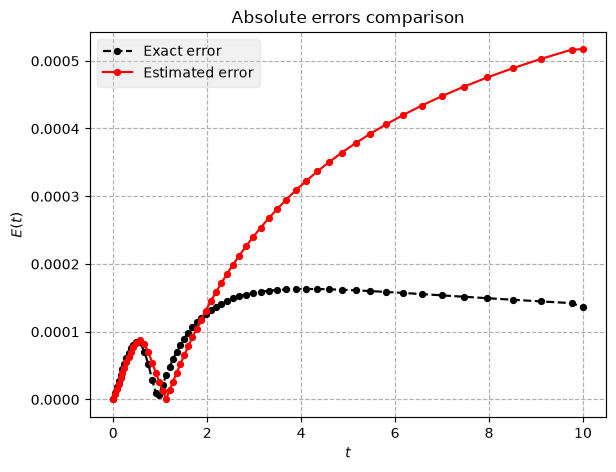

In [8]:
# Global error plot comparison
plt.title('Absolute errors comparison')
plt.plot(t, exact_err, linestyle = 'dashed', marker = 'o', markersize = 4, color = 'black', label = 'Exact error')
plt.plot(t, err, linestyle = 'solid', marker = 'o', markersize = 4, color = 'red', label = 'Estimated error')
plt.xlabel(r'$t$')
plt.ylabel(r'$E(t)$')
plt.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
plt.grid(linestyle = 'dashed')
plt.show()

In [9]:
# Direct comparison: only the first significant digit actually matters
for err1, err2 in zip(err, exact_err):
    print(f"{err1:.1g} vs {err2:.1g}")

0 vs 0
8e-06 vs 1e-05
2e-05 vs 2e-05
2e-05 vs 3e-05
3e-05 vs 4e-05
4e-05 vs 4e-05
5e-05 vs 5e-05
5e-05 vs 6e-05
6e-05 vs 7e-05
7e-05 vs 8e-05
8e-05 vs 8e-05
8e-05 vs 8e-05
9e-05 vs 8e-05
8e-05 vs 7e-05
7e-05 vs 5e-05
5e-05 vs 3e-05
4e-05 vs 1e-05
3e-05 vs 7e-06
1e-05 vs 2e-05
2e-07 vs 4e-05
1e-05 vs 5e-05
3e-05 vs 6e-05
4e-05 vs 7e-05
5e-05 vs 8e-05
6e-05 vs 9e-05
8e-05 vs 0.0001
9e-05 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0001
0.0002 vs 0.0001
0.0002 vs 0.0001
0.0002 vs 0.0001
0.0002 vs 0.0001
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0003 vs 0.0002
0.0003 vs 0.0002
0.0003 vs 0.0002
0.0003 vs 0.0002
0.0003 vs 0.0002
0.0003 vs 0.0002
0.0003 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0004 vs 0.0002
0.0005 vs 0.0002
0.0005 vs 0.0001
0.0005 vs 0.0001
0.0005 vs 0.0001
0.0005 vs 0.0001
0.0005 vs 0.0001


Let's test on:

$$
    y'(t) = e^{- t \, y(t)} \quad y(0) = 1
$$

This cannot be solved analytically

In [10]:
def g(t, y): return np.exp(- t * y) # rhs of ODE
def gprime(t, y): return - t * np.exp(- t * y) # Partial derivative with respect to y

# Setup
t0, T = 0.0, 6.0
y0 = 1.0
h0 = 0.1 # Inital step

In [11]:
t, y, err = CN_adaptive( # Solution and estimated absolute errors
    g = g,
    gprime = gprime,
    t0 = t0,
    y0 = y0,
    h0 = h0,
    t_end = T,
    atol = 0.0 # atol = 0, rtol = 1e-05
    )

t, y, err

(array([0.        , 0.05675933, 0.10853814, 0.17556315, 0.23551217,
        0.29458265, 0.35413263, 0.40922746, 0.46219744, 0.51423604,
        0.56599742, 0.61791252, 0.67030168, 0.72342431, 0.77750467,
        0.83274681, 0.88934416, 0.94748616, 1.00736326, 1.06917101,
        1.13311371, 1.19940781, 1.26828552, 1.33999849, 1.41482202,
        1.49305989, 1.57504997, 1.66117105, 1.75185104, 1.84757724,
        1.94890911, 2.05649455, 2.17109082, 2.29359186, 2.42506451,
        2.56679731, 2.72036746, 2.88773455, 3.07137495, 3.27447941,
        3.50125264, 3.75738394, 4.05081766, 4.39307993, 4.80170716,
        5.30504591, 5.95272169, 6.        ]),
 array([1.        , 1.05510964, 1.10246378, 1.15953672, 1.20655053,
        1.24922204, 1.28869468, 1.32218415, 1.35178104, 1.37851762,
        1.40295405, 1.42544506, 1.44623716, 1.46551259, 1.48341226,
        1.50004898, 1.51551569, 1.52989081, 1.54324186, 1.55562808,
        1.56710226, 1.57771215, 1.58750157, 1.59651114, 1.60477905,
  

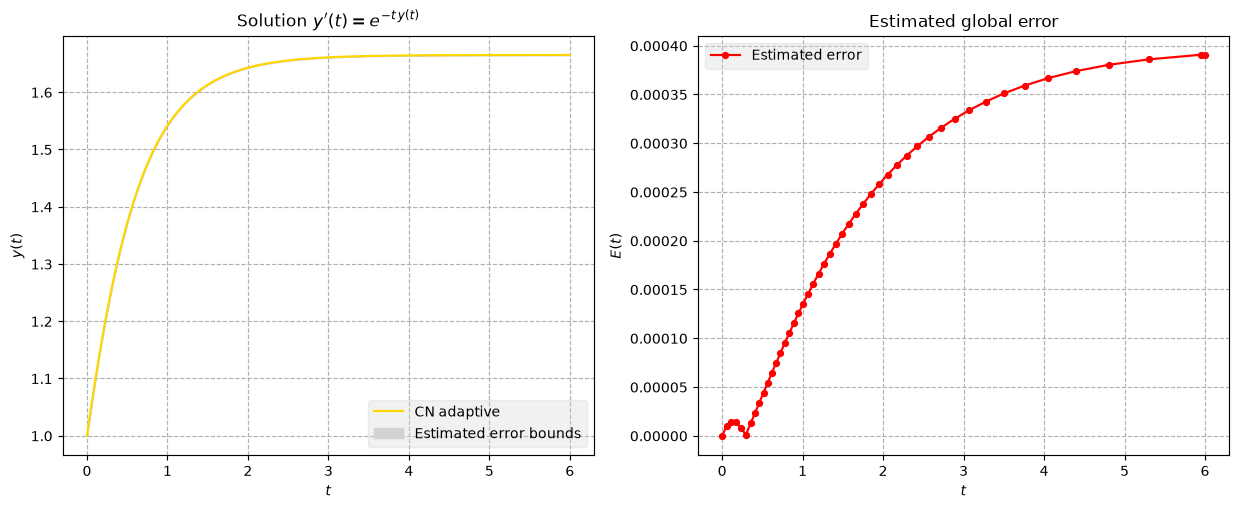

In [12]:
# Plotting
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Solution
ax1.set_title(r"Solution $y'(t) = e^{- t \, y(t)}$")
ax1.plot(t, y, color = 'gold', label = 'CN adaptive')
ax1.fill_between(t, y - err, y + err, color = 'lightgray', alpha = 1.0, label = 'Estimated error bounds')
ax1.set_xlabel(r'$t$')
ax1.set_ylabel(r'$y(t)$')
ax1.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax1.grid(linestyle = 'dashed')

# Error estimation
ax2.set_title('Estimated global error')
ax2.plot(t, err, linestyle = 'solid', marker = 'o', markersize = 4, color = 'red', label = 'Estimated error')
ax2.set_xlabel(r'$t$')
ax2.set_ylabel(r'$E(t)$')
ax2.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax2.grid(linestyle = 'dashed')

plt.tight_layout()
plt.show()

Let's try another method based on quadratic spline interpolation to estimate the global absolute errors of our solution

In [13]:
t2, y2, _ = CN_adaptive( # Solution using CN adaptive, low tolerances though
    g = g,
    gprime = gprime,
    t0 = t0,
    y0 = y0,
    h0 = h0,
    t_end = T,
    atol = 0.0,
    rtol = 1e-08 # 1000 times smaller
    )

Y = make_interp_spline( # Quadratic spline interpolation of y2(t2)
    x = t2,
    y = y2,
    k = 2 # Quadratic
)

Y

In [14]:
err_CN = np.abs(Y(t) - y) # Estimated absolute errors of y using interpolated curve
err_CN

array([0.00000000e+00, 1.17296179e-05, 1.59437795e-05, 1.55090912e-05,
       9.08862622e-06, 1.27337714e-06, 1.49764822e-05, 2.73230487e-05,
       3.89818693e-05, 5.02724300e-05, 6.13216898e-05, 7.21894005e-05,
       8.29075317e-05, 9.34945899e-05, 1.03961835e-04, 1.14318748e-04,
       1.24573576e-04, 1.34731064e-04, 1.44794529e-04, 1.54767357e-04,
       1.64660253e-04, 1.74476980e-04, 1.84218578e-04, 1.93896498e-04,
       2.03516834e-04, 2.13079605e-04, 2.22599768e-04, 2.32076889e-04,
       2.41519280e-04, 2.50932984e-04, 2.60318924e-04, 2.69683985e-04,
       2.79026852e-04, 2.88345948e-04, 2.97642724e-04, 3.06901507e-04,
       3.16114688e-04, 3.25265837e-04, 3.34325110e-04, 3.43256269e-04,
       3.52011273e-04, 3.60524205e-04, 3.68705945e-04, 3.76446697e-04,
       3.83585701e-04, 3.89926769e-04, 3.95210944e-04, 3.95205222e-04])

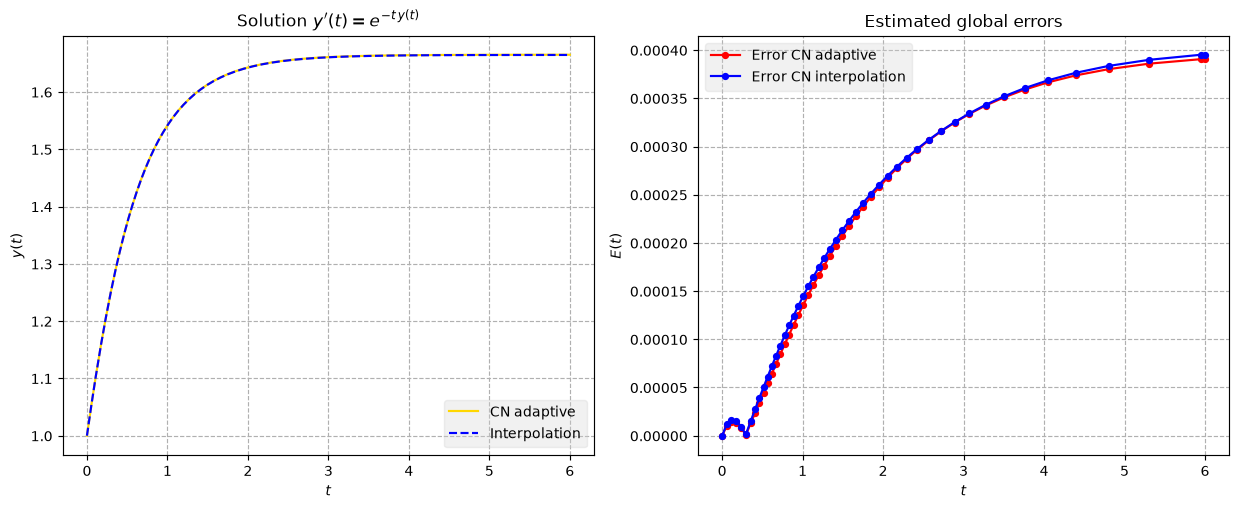

In [15]:
# Plotting
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Solution
ax1.set_title(r"Solution $y'(t) = e^{- t \, y(t)}$")
ax1.plot(t, y, color = 'gold', label = 'CN adaptive')
ax1.plot(t, Y(t), color = 'blue', linestyle = 'dashed', label = 'Interpolation')
ax1.set_xlabel(r'$t$')
ax1.set_ylabel(r'$y(t)$')
ax1.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax1.grid(linestyle = 'dashed')

# Error estimation
ax2.set_title('Estimated global errors')
ax2.plot(t, err, linestyle = 'solid', marker = 'o', markersize = 4, color = 'red', label = 'Error CN adaptive')
ax2.plot(t, err_CN, linestyle = 'solid', marker = 'o', markersize = 4, color = 'blue', label = 'Error CN interpolation')
ax2.set_xlabel(r'$t$')
ax2.set_ylabel(r'$E(t)$')
ax2.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax2.grid(linestyle = 'dashed')

plt.tight_layout()
plt.show()

For this ODE, the interpolation method yields same global errors

In [16]:
for err1, err2 in zip(err, err_CN): # Direct comparison. Actually, only the first significant digit matters
    print(f"{err1:.1g} vs {err2:.1g}")

0 vs 0
1e-05 vs 1e-05
1e-05 vs 2e-05
1e-05 vs 2e-05
8e-06 vs 9e-06
8e-07 vs 1e-06
1e-05 vs 1e-05
2e-05 vs 3e-05
3e-05 vs 4e-05
4e-05 vs 5e-05
5e-05 vs 6e-05
6e-05 vs 7e-05
7e-05 vs 8e-05
8e-05 vs 9e-05
9e-05 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0001
0.0001 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0002
0.0002 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0003 vs 0.0003
0.0004 vs 0.0004
0.0004 vs 0.0004
0.0004 vs 0.0004
0.0004 vs 0.0004
0.0004 vs 0.0004
0.0004 vs 0.0004
0.0004 vs 0.0004
0.0004 vs 0.0004


Let's try the interpolation method again for the first ODE instead

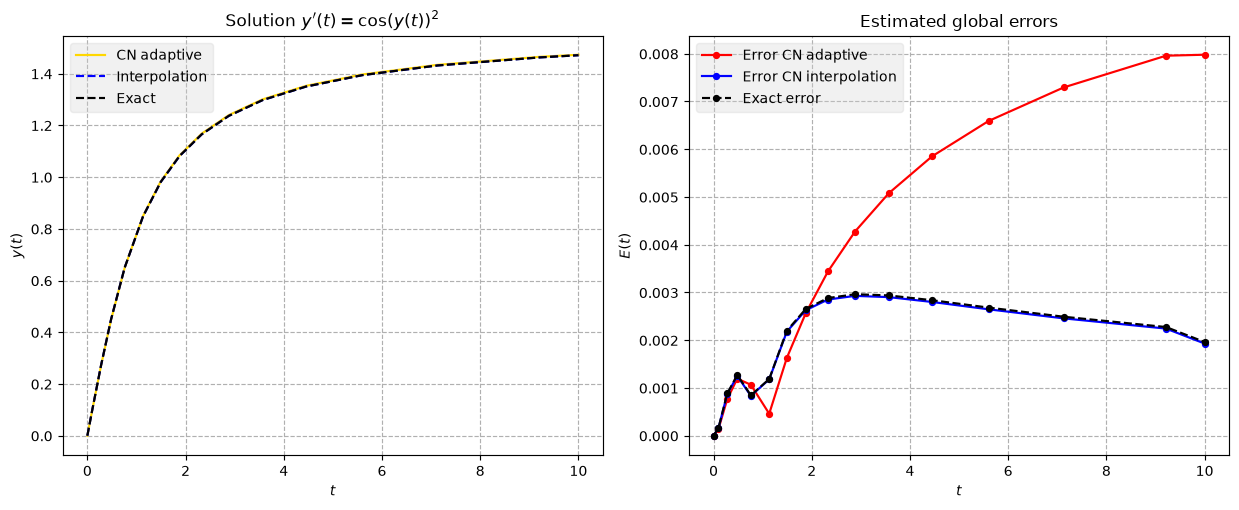

In [17]:
def g(t, y): return np.cos(y) ** 2 # rhs of ODE
def gprime(t, y): return - np.sin(2.0 * y) # Partial derivative with respect to y

# Setup
t0, T = 0.0, 10.0
y0 = 0.0
h0 = 0.1 # Inital step

t, y, err = CN_adaptive( # Solution and estimated absolute errors
    g = g,
    gprime = gprime,
    t0 = t0,
    y0 = y0,
    h0 = h0,
    t_end = T,
    atol = 1e-03, # Higher tolerances
    rtol = 1e-03
    )

t2, y2, _ = CN_adaptive( # Solution using CN adaptive, low tolerances though
    g = g,
    gprime = gprime,
    t0 = t0,
    y0 = y0,
    h0 = h0,
    t_end = T,
    atol = 1e-06, # Lower tolerances
    rtol = 1e-06
    )

Y = make_interp_spline( # Quadratic spline interpolation of y2(t2)
    x = t2,
    y = y2,
    k = 2 # Quadratic
)

err_CN = np.abs(Y(t) - y) # Estimated absolute errors of y using interpolated curve

exact_sol = sol_exact(t) # Exact solution
exact_err = np.abs(exact_sol - y) # Exact error

# Plotting
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Solution
ax1.set_title(r"Solution $y'(t) = \cos(y(t))^{2}$")
ax1.plot(t, y, color = 'gold', label = 'CN adaptive')
ax1.plot(t, Y(t), color = 'blue', linestyle = 'dashed', label = 'Interpolation')
ax1.plot(t, exact_sol, color = 'black', linestyle = 'dashed', label = 'Exact')
ax1.set_xlabel(r'$t$')
ax1.set_ylabel(r'$y(t)$')
ax1.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax1.grid(linestyle = 'dashed')

# Error estimation
ax2.set_title('Estimated global errors')
ax2.plot(t, err, linestyle = 'solid', marker = 'o', markersize = 4, color = 'red', label = 'Error CN adaptive')
ax2.plot(t, err_CN, linestyle = 'solid', marker = 'o', markersize = 4, color = 'blue', label = 'Error CN interpolation')
ax2.plot(t, exact_err, linestyle = 'dashed', marker = 'o', markersize = 4, color = 'black', label = 'Exact error')
ax2.set_xlabel(r'$t$')
ax2.set_ylabel(r'$E(t)$')
ax2.legend(loc = 'best', frameon = True, facecolor = 'lightgray', framealpha = 0.3)
ax2.grid(linestyle = 'dashed')

plt.tight_layout()
plt.show()

For the first ODE, the interpolation method yields perfectly the exact global absolute errors!